In [11]:
## Make perturbation experiments
import sys
sys.path.insert(0,"/g/data/gb02/ab8992/regional-mom6/dev/mom6_forge")
sys.path.insert(0,"/g/data/gb02/ab8992/regional-mom6/dev/regional-mom6")
import warnings
warnings.filterwarnings("ignore")
import xarray as xr

import os
from pathlib import Path
import regional_mom6 as rmom6


def IC_from_restart(basepath,expt,restart,out_path,start_date):
    rundir = basepath / expt
    restart = xr.open_mfdataset(str(basepath / expt / "archive" / restart / "access-om3.mom6.r.*"))[["Temp","Salt","u","v","sfc"]].isel(Time = 0)
    restart.to_netcdf(out_path / "raw_IC_data.nc",mode = "w")

    ## Put links to the hgrid and vgrid in the out_path so we can treat that as our run directory
    (out_path / "hgrid.nc").symlink_to(basepath / expt / "inputdir" / "hgrid.nc")
    (out_path / "vcoord.nc").symlink_to(basepath / expt / "inputdir" / "vcoord.nc")

    expt = rmom6.experiment(              
        date_range = [start_date, "2013-01-30"],
        hgrid_type="from_file",
        vgrid_type="from_file",
        tidal_constituents=[],
        mom_run_dir = "na",
        mom_input_dir = out_path,
    )

    ocean_varnames = {"time": "time",
                  "yh": "lath", 
                  "xh": "lonh",
                  "yq": "latq", 
                  "xq": "lonq",                  
                  "zl": "Layer",
                  "eta": "sfc",
                  "u": "u",
                  "v": "v",
                  "tracers": {"salt": "Salt", "temp": "Temp"} # You can have as many tracers here as you like, and they will all get regridded to your ICs / BCs
                  }

    # Set up the initial condition.
    expt.setup_initial_condition(
        expt.mom_input_dir / "raw_IC_data.nc",
        ocean_varnames,
        arakawa_grid = "C"
        )

    return

basepath = Path("/g/data/gb02/ab8992/rom3-rundirs/")
expt = "nino-12th"
out_path = Path("/g/data/x77/ab8992/nino-34/restarts/jan2009-12th")
IC_from_restart(basepath,expt,"restart011",out_path,"2009-01-01")



Applying Arakawa C grid variable mapping, which is u-velocity on xq, yh; v-velocity on xh, yq; and tracers on xh, yh.


Setting up Initial Conditions
Regridding Velocities... Done.
Regridding Tracers... Done.
Regridding Free surface... Done.


FileNotFoundError: Vertical grid /g/data/x77/ab8992/nino-34/restarts/jan2009-12th/vgrid.nc not found. Make sure `vgrid.nc` exists in /g/data/x77/ab8992/nino-34/restarts/jan2009-12th directory, or pass in a VGrid object via `vgrid_type`.

In [ ]:
import xarray as xr
import numpy as np
import os
from pathlib import Path

def perterb_ic(restart_path,n = 5):
    """
    Restart path contains a folder called 'original' which has a copy of all the unmodified restart files
    Makes a new folder at restart_path for each perturbation p_1, p_2 etc. These have perturbed velocities
    but all other fields are symlinked back to original
    """

    # Find the file containing u and v
    for f in (restart_path / f"{restart_path.name}_original").glob(pattern="access-om3.mom6.r.*"):
        print(f)
        with xr.open_dataset(str(f)) as d:
            if "u" in d.data_vars:
                ufile = f
            if "v" in d.data_vars:
                vfile = f

    files = [i for i in (restart_path / f"{restart_path.name}_original").glob("*")]

    # Now in the out path, make a perturbed version of this IC. Make symlinks to all the other files
    u = xr.open_dataset(ufile)
    v = xr.open_dataset(vfile)
    for i in range(n):
        outpath = restart_path / f"{restart_path.name}_{i}"
        outpath.mkdir(exist_ok = True)
        # Symlink all the restart files aside from the u and v containing file(s)
        for f in files:
            if f.name != ufile.name and f.name != vfile.name: 
                (outpath / f.name).unlink(missing_ok = True)
                (outpath / f.name).symlink_to(f)

        # Now, if the file containing u is the same as v, handle them both together
        if ufile == vfile:
            print("u and v both in the same restart file. Perturbing this one file")
            u_p = u
            u_p["u"] += 1e-03 * np.random.random(size = u["u"].shape)
            u_p["v"] += 1e-03 * np.random.random(size = u["v"].shape)
            u_p.attrs = u.attrs
            u_p.to_netcdf(outpath / ufile.name,mode = "w")

        else:
            raise NotImplemented("U and V not in the same restart file")
        
    return None



/g/data/x77/ab8992/nino-34/restarts/jan2009-12th/jan2009-12th_original/access-om3.mom6.r.2009-01-01-00000.nc
u and v both in the same restart file. Perturbing this one file
u and v both in the same restart file. Perturbing this one file
u and v both in the same restart file. Perturbing this one file
u and v both in the same restart file. Perturbing this one file
u and v both in the same restart file. Perturbing this one file


## Make perturbations for 12th degree based on jan 1 2009

In [ ]:
basepath = Path("/g/data/x77/ab8992/nino-34/restarts/jan2009-12th")
perterb_ic(basepath,5)

## Make the archive directories for each perturbation
expt = "nino-12th"
work = Path("/scratch/x77/ab8992/access-om3/archive")
basepath = Path("/g/data/x77/ab8992/nino-34/restarts/jan2009-12th")
for i in range(5):
    archive = work / f"{expt}_{i}"
    (archive / "output000").mkdir(parents= True)
    (archive / "restart000").symlink_to(basepath / f"{basepath.name}_{i}")

## ditto for 25th

In [20]:
basepath = Path("/g/data/x77/ab8992/nino-34/restarts/jan2009-25th")
perterb_ic(basepath,2)

## Make the archive directories for each perturbation
expt = "nino-25th"
work = Path("/scratch/x77/ab8992/access-om3/archive")
basepath = Path("/g/data/x77/ab8992/nino-34/restarts/jan2009-25th")
for i in range(5):
    archive = work / f"{expt}_{i}"
    (archive / "output000").mkdir(parents= True)
    (archive / "restart000").symlink_to(basepath / f"{basepath.name}_{i}")

/g/data/x77/ab8992/nino-34/restarts/jan2009-25th/jan2009-25th_original/access-om3.mom6.r.2009-01-01-00000_2.nc
/g/data/x77/ab8992/nino-34/restarts/jan2009-25th/jan2009-25th_original/access-om3.mom6.r.2009-01-01-00000.nc
/g/data/x77/ab8992/nino-34/restarts/jan2009-25th/jan2009-25th_original/access-om3.mom6.r.2009-01-01-00000_1.nc
u and v both in the same restart file. Perturbing this one file
u and v both in the same restart file. Perturbing this one file


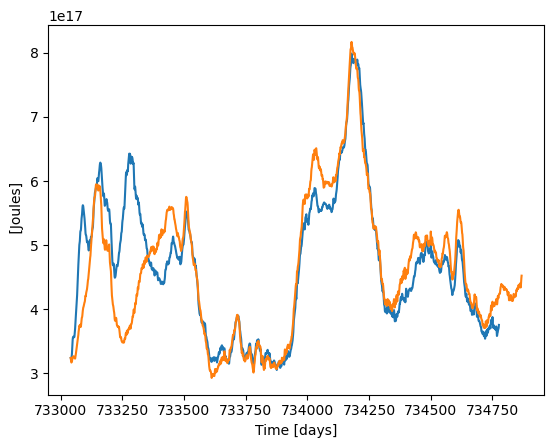

In [19]:
s = xr.open_mfdataset("/g/data/gb02/ab8992/rom3-rundirs/nino-25th/archive/output*/ocean.stats.nc")
(s.KE.sum("Layer") + s.APE.sum("Interface")).plot()
s1 = xr.open_mfdataset("/g/data/gb02/ab8992/rom3-rundirs/nino-12th/archive/output*/ocean.stats.nc")
(s1.KE.sum("Layer") + s1.APE.sum("Interface")).plot()

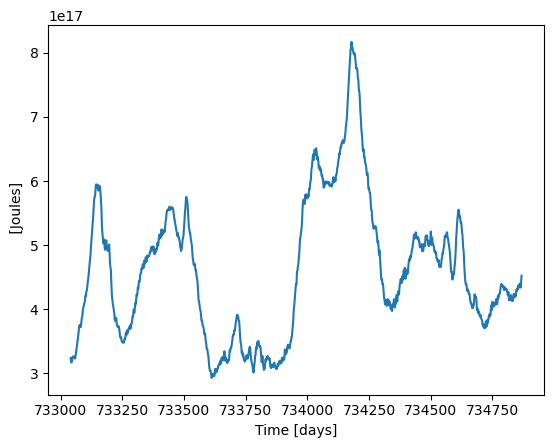

In [18]:
s = xr.open_mfdataset("/g/data/gb02/ab8992/rom3-rundirs/nino-12th/archive/output*/ocean.stats.nc")
(s.KE.sum("Layer") + s.APE.sum("Interface")).plot()